In [33]:
import pandas as pd
import importlib
import funciones as f #Tener funciones.py en mismo directorio. Tiene las funciones usadas para procesar un df
importlib.reload(f)

data = pd.read_csv('competition_data.csv')
submission = pd.read_csv('submission.csv')
submission_aux = pd.read_csv('submission.csv')

### Descomentar la siguiente celda la primera vez que se corre el notebook

In [34]:
# uri_to_ms_data = f.get_songs_durations(data)
# uri_to_ms_submission = f.get_songs_durations(submission)
# diccionario = {**uri_to_ms_data, **uri_to_ms_submission}

In [35]:
data = f.procesar_df(data, diccionario)

In [36]:
data.columns

Index(['Unnamed: 0', 'ts', 'platform', 'master_metadata_track_name',
       'master_metadata_album_artist_name', 'master_metadata_album_album_name',
       'spotify_track_uri', 'reason_start', 'shuffle', 'TARGET', 'hour',
       'day_of_week', 'month', 'year', 'is_iphone', 'duration_ms',
       'is_early_finish', 'reason_appload', 'reason_backbtn',
       'reason_clickrow', 'reason_fwdbtn', 'reason_playbtn', 'reason_remote',
       'reason_trackdone', 'reason_trackerror', 'reason_unknown', 'track_prop',
       'artist_prop', 'album_prop', 'hour day_of_week'],
      dtype='object')

In [37]:
import xgboost as xgb

drop_cols = [
    'Unnamed: 0','ts','TARGET', 'platform', 'reason_start',
    'master_metadata_track_name',
    'master_metadata_album_artist_name',
    'master_metadata_album_album_name',
    'spotify_track_uri','platform'
]
clf_xgb = xgb.XGBClassifier(objective = 'binary:logistic',
                            seed = 42,
                            eval_metric = 'auc')
clf_xgb.fit(data.drop(columns=drop_cols), data['TARGET'])

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

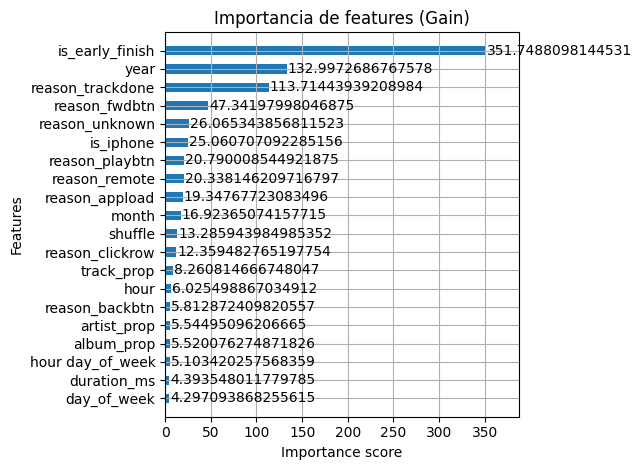

In [38]:
import matplotlib.pyplot as plt
xgb.plot_importance(clf_xgb, importance_type='gain', max_num_features=20, height=0.5)
plt.title("Importancia de features (Gain)")
plt.tight_layout()
plt.show()

In [40]:
data = pd.read_csv('competition_data.csv')

In [41]:
submission = f.procesar_df_2(submission, diccionario)

In [42]:
union = pd.concat([data, submission_aux], axis=0)

In [49]:
union.columns

Index(['Unnamed: 0', 'ts', 'platform', 'master_metadata_track_name',
       'master_metadata_album_artist_name', 'master_metadata_album_album_name',
       'spotify_track_uri', 'reason_start', 'shuffle', 'TARGET', 'hour',
       'day_of_week', 'month', 'year', 'is_iphone', 'duration_ms',
       'is_early_finish', 'reason_appload', 'reason_backbtn',
       'reason_clickrow', 'reason_fwdbtn', 'reason_playbtn', 'reason_remote',
       'reason_trackdone', 'reason_trackerror', 'reason_unknown', 'track_prop',
       'artist_prop', 'album_prop', 'hour day_of_week'],
      dtype='object')

In [44]:
union = f.procesar_df(union, diccionario)

In [ ]:
submission = submission.merge(
    union[['Unnamed: 0', 'is_early_finish']],
    on='Unnamed: 0',
    how='left'
)

In [51]:
submission = submission[['Unnamed: 0', 'ts', 'platform', 'master_metadata_track_name',
       'master_metadata_album_artist_name', 'master_metadata_album_album_name',
       'spotify_track_uri', 'reason_start', 'shuffle', 'hour',
       'day_of_week', 'month', 'year', 'is_iphone', 'duration_ms',
       'is_early_finish', 'reason_appload', 'reason_backbtn',
       'reason_clickrow', 'reason_fwdbtn', 'reason_playbtn', 'reason_remote',
       'reason_trackdone', 'reason_trackerror', 'reason_unknown', 'track_prop',
       'artist_prop', 'album_prop', 'hour day_of_week']]

In [52]:
drop_cols = [
    'Unnamed: 0','ts', 'platform', 'reason_start',
    'master_metadata_track_name',
    'master_metadata_album_artist_name',
    'master_metadata_album_album_name',
    'spotify_track_uri','platform'
]

prediccion_submmit = clf_xgb.predict_proba(submission.drop(columns=drop_cols))[:, 1]

In [53]:
results = pd.DataFrame({'ID': submission['Unnamed: 0'], 'TARGET': prediccion_submmit})
results = results.set_index('ID').loc[submission_aux['Unnamed: 0']].reset_index()
results.to_csv('submission18.csv', index=False)